# Modeling 1D

SimPEG has been slowly included into mtpy. The most basic inversion is 1D.  Here, a few different methods for inverting data in 1D are presented.  

In [1]:
from pathlib import Path
import numpy as np
from matplotlib import pyplot as plt

from mtpy import MTCollection

In [2]:
with MTCollection() as mc:
    mc.open_collection(Path(r"c:\Users\jpeacock\OneDrive - DOI\SAGE\sage_2026.h5"))
    md = mc.to_mt_data()


26:06:26T21:00:19 | INFO | line:1035 |mth5.mth5 | close_mth5 | Flushing and closing c:\Users\jpeacock\OneDrive - DOI\SAGE\sage_2026.h5


In [3]:

from ipywidgets import widgets, interact
station_names = [s.replace("surveys/", "").replace("stations/", "") for s in md.station_paths]
def foo(name, component):
    tf = md.get_station(name, as_mt=True)
    tf.plot_mt_response(plot_num=3)
Q = interact(
    foo, 
    name=widgets.Select(options=station_names, value="SAGE2026/sg2602"),
    component=widgets.RadioButtons(options=['xy', 'yx', 'det'], value='det')
)

interactive(children=(Select(description='name', index=46, options=('SAGE2017/SG1702', 'SAGE2017/SG1704', 'SAG…

Text(0.5, 1.0, 'SAGE2026/sg2602')

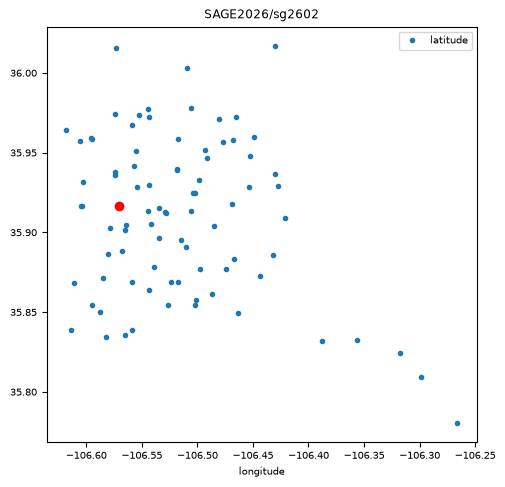

In [4]:
name = Q.widget.kwargs['name']
component = Q.widget.kwargs['component']
tf = md.get_station(name, as_mt=True)

fig, ax = plt.subplots(1,1, figsize=(5,5))
md.station_locations.plot(x='longitude', y='latitude', marker='.', linestyle='None', ax=ax)
ax.plot(tf.longitude, tf.latitude, 'ro')
ax.set_title(name)

26:06:26T21:00:34 | INFO | line:1586 |mtpy.core.mt | to_simpeg_1d | Using default errors for impedance


INFO: 
simpeg.InvProblem is setting bfgsH0 to the inverse of the reg.deriv2.
using the default solver SolverLU with the 'is_symmetric=True` option set.

INFO: Directive TargetMisfit: Target data misfit is 128.0



Running inversion with SimPEG v0.25.2
============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
   0  5.59e+02  3.51e+03  0.00e+00  3.51e+03                                 
   1  5.59e+02  4.26e+02  1.22e-03  4.27e+02    1.58e+03      0              
   2  2.80e+02  1.81e+02  7.53e-03  1.83e+02    2.67e+02      0   Skip BFGS  
   3  1.40e+02  9.97e+01  2.60e-02  1.03e+02    7.25e+01      0              
------------------------- STOP! -------------------------
1 : |fc-fOld| = 7.8679e+01 <= tolF*(1+|f0|) = 3.5158e+02
0 : |xc-x_last| = 2.4271e+01 <= tolX*(1+|x0|) = 3.3887e+00
0 : |proj(x-g)-x|    = 7.2541e+01 <= tolG          = 1.0000e-01
0 : |proj(x-g)-x|    = 7.2541e+01 <= 1e3*eps       = 1.0000e-02
0 : maxIter   =      40    <= iter          =      3
------------------------- DONE! -------------------------


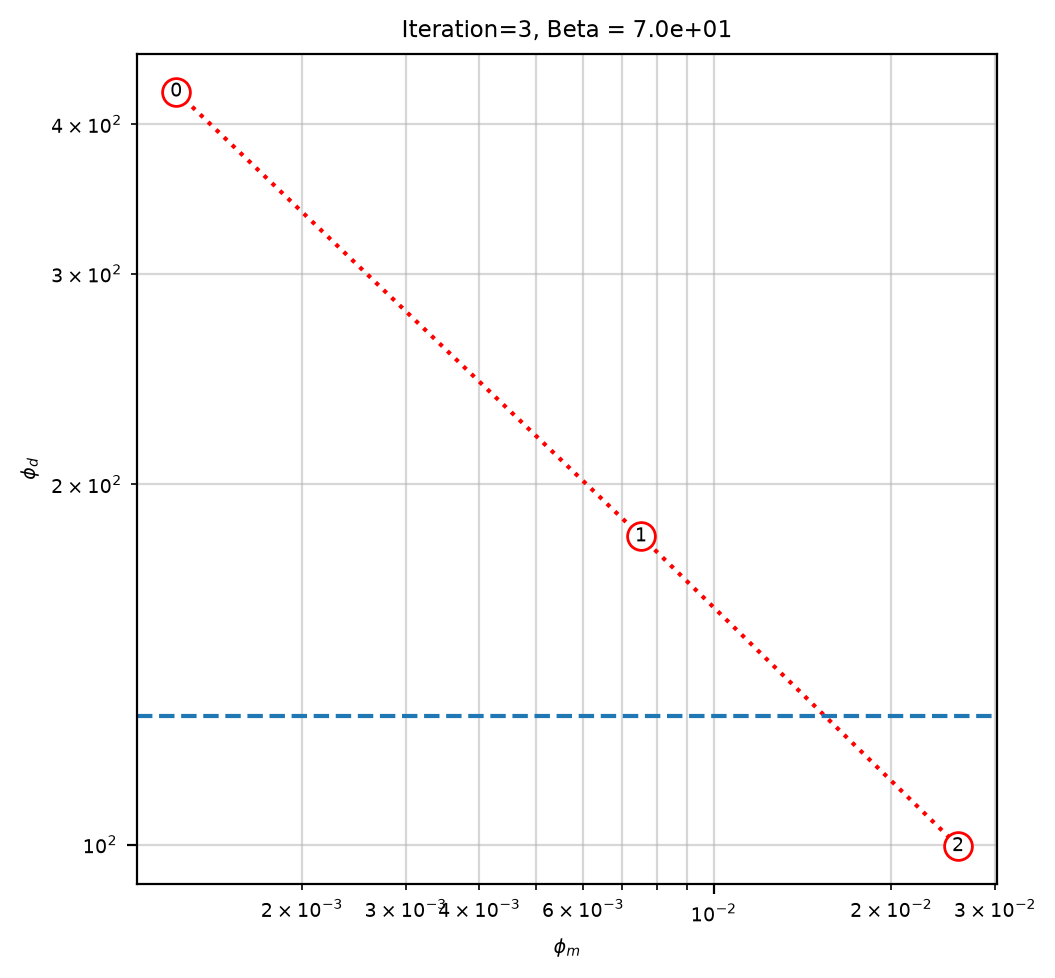

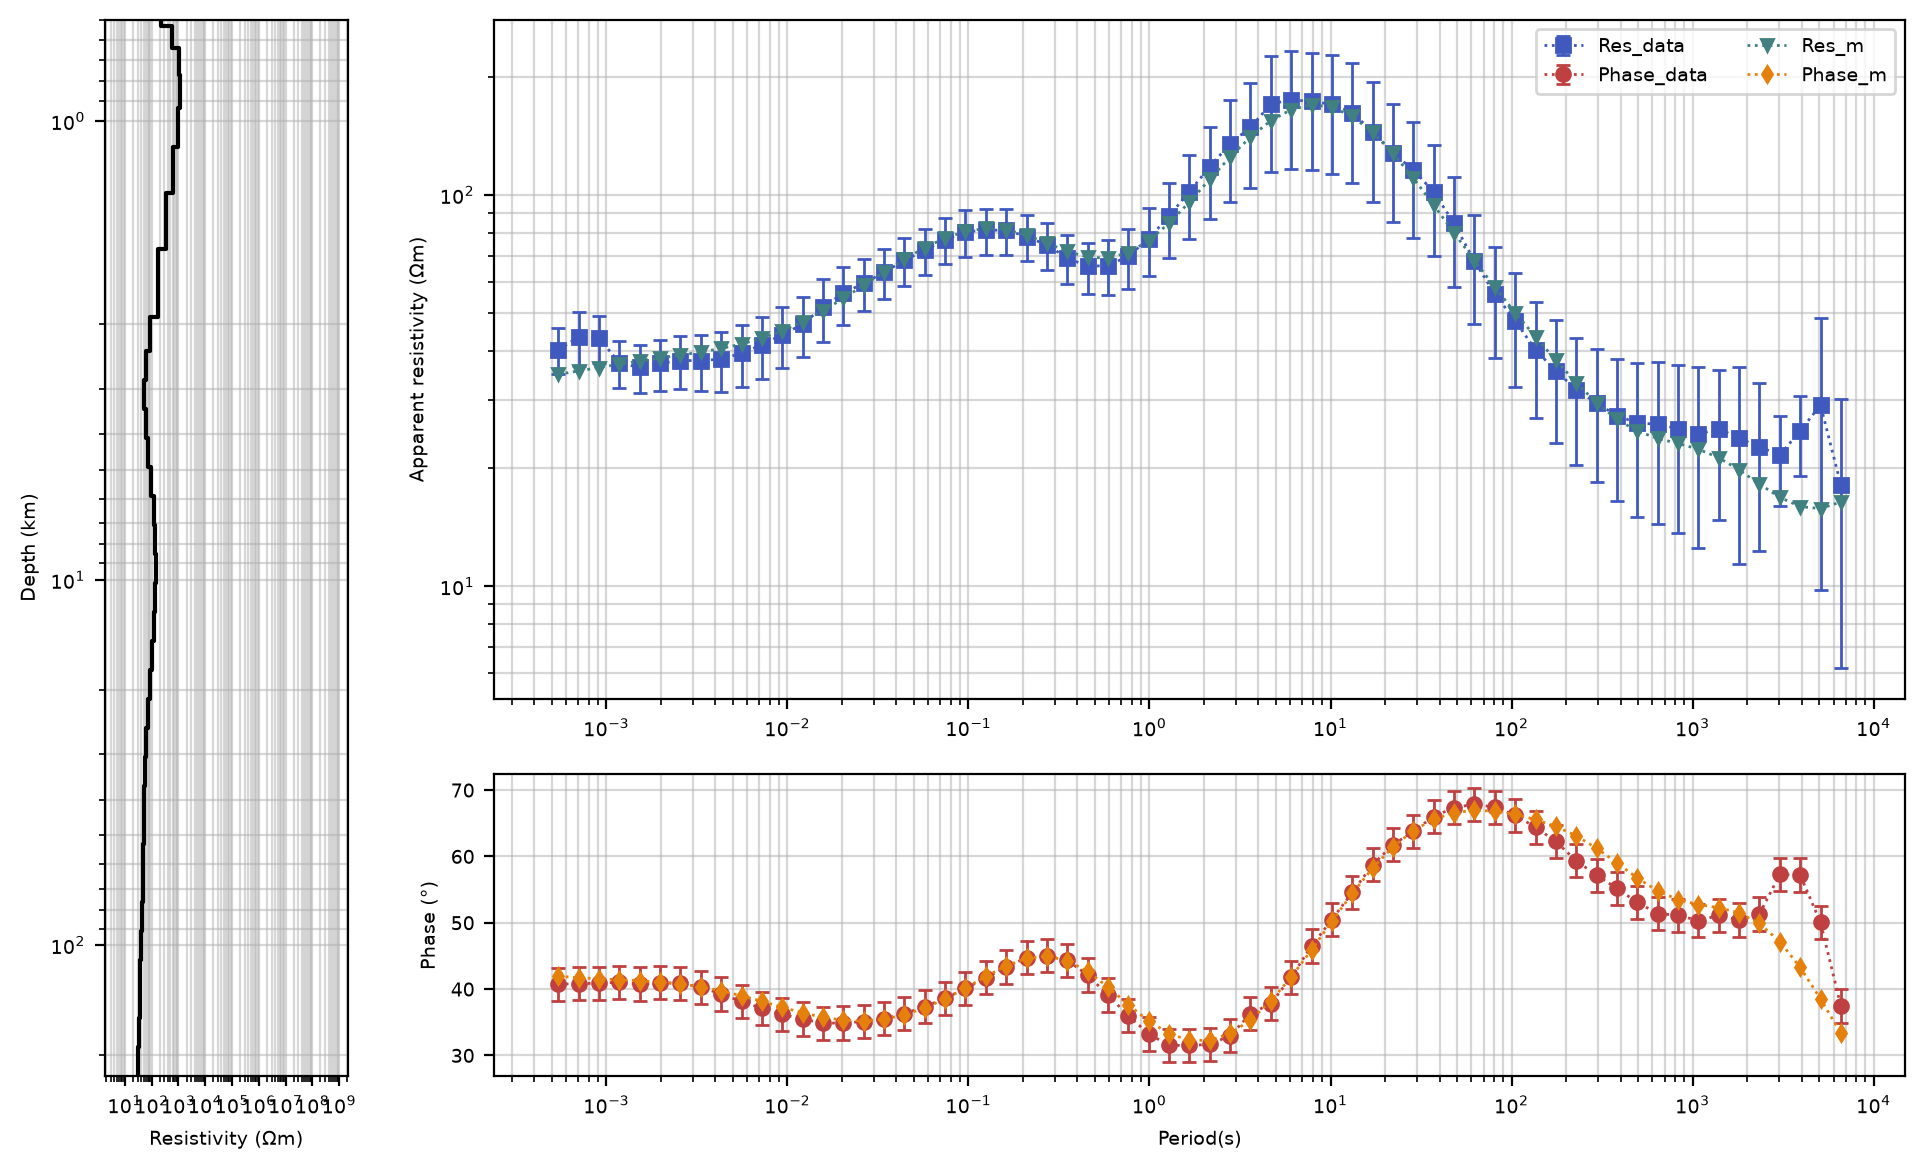

In [5]:
inv_obj = tf.to_simpeg_1d(mode="det")

INFO: 
simpeg.InvProblem is setting bfgsH0 to the inverse of the reg.deriv2.
using the default solver SolverLU with the 'is_symmetric=True` option set.

INFO: Directive TargetMisfit: Target data misfit is 128.0



Running inversion with SimPEG v0.25.2
============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
   0  1.68e+03  1.08e+04  0.00e+00  1.08e+04                                 
   1  1.68e+03  1.05e+03  7.18e-04  1.05e+03    5.24e+03      0              
   2  8.42e+02  2.16e+02  5.49e-03  2.21e+02    6.95e+02      0   Skip BFGS  
   3  4.21e+02  8.55e+01  1.12e-02  9.03e+01    1.76e+02      0              
------------------------- STOP! -------------------------
1 : |fc-fOld| = 1.2848e+02 <= tolF*(1+|f0|) = 1.0838e+03
0 : |xc-x_last| = 1.1677e+01 <= tolX*(1+|x0|) = 3.3887e+00
0 : |proj(x-g)-x|    = 1.7576e+02 <= tolG          = 1.0000e-01
0 : |proj(x-g)-x|    = 1.7576e+02 <= 1e3*eps       = 1.0000e-02
0 : maxIter   =      40    <= iter          =      3
------------------------- DONE! -------------------------


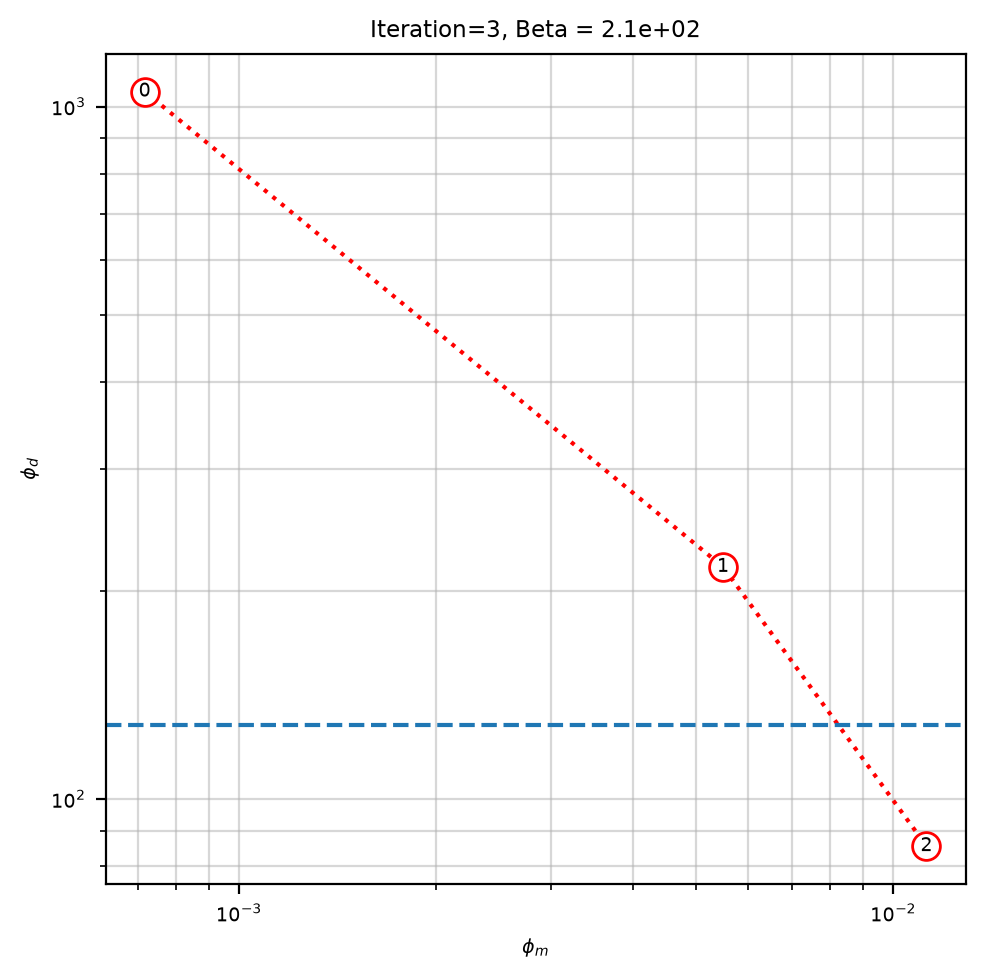

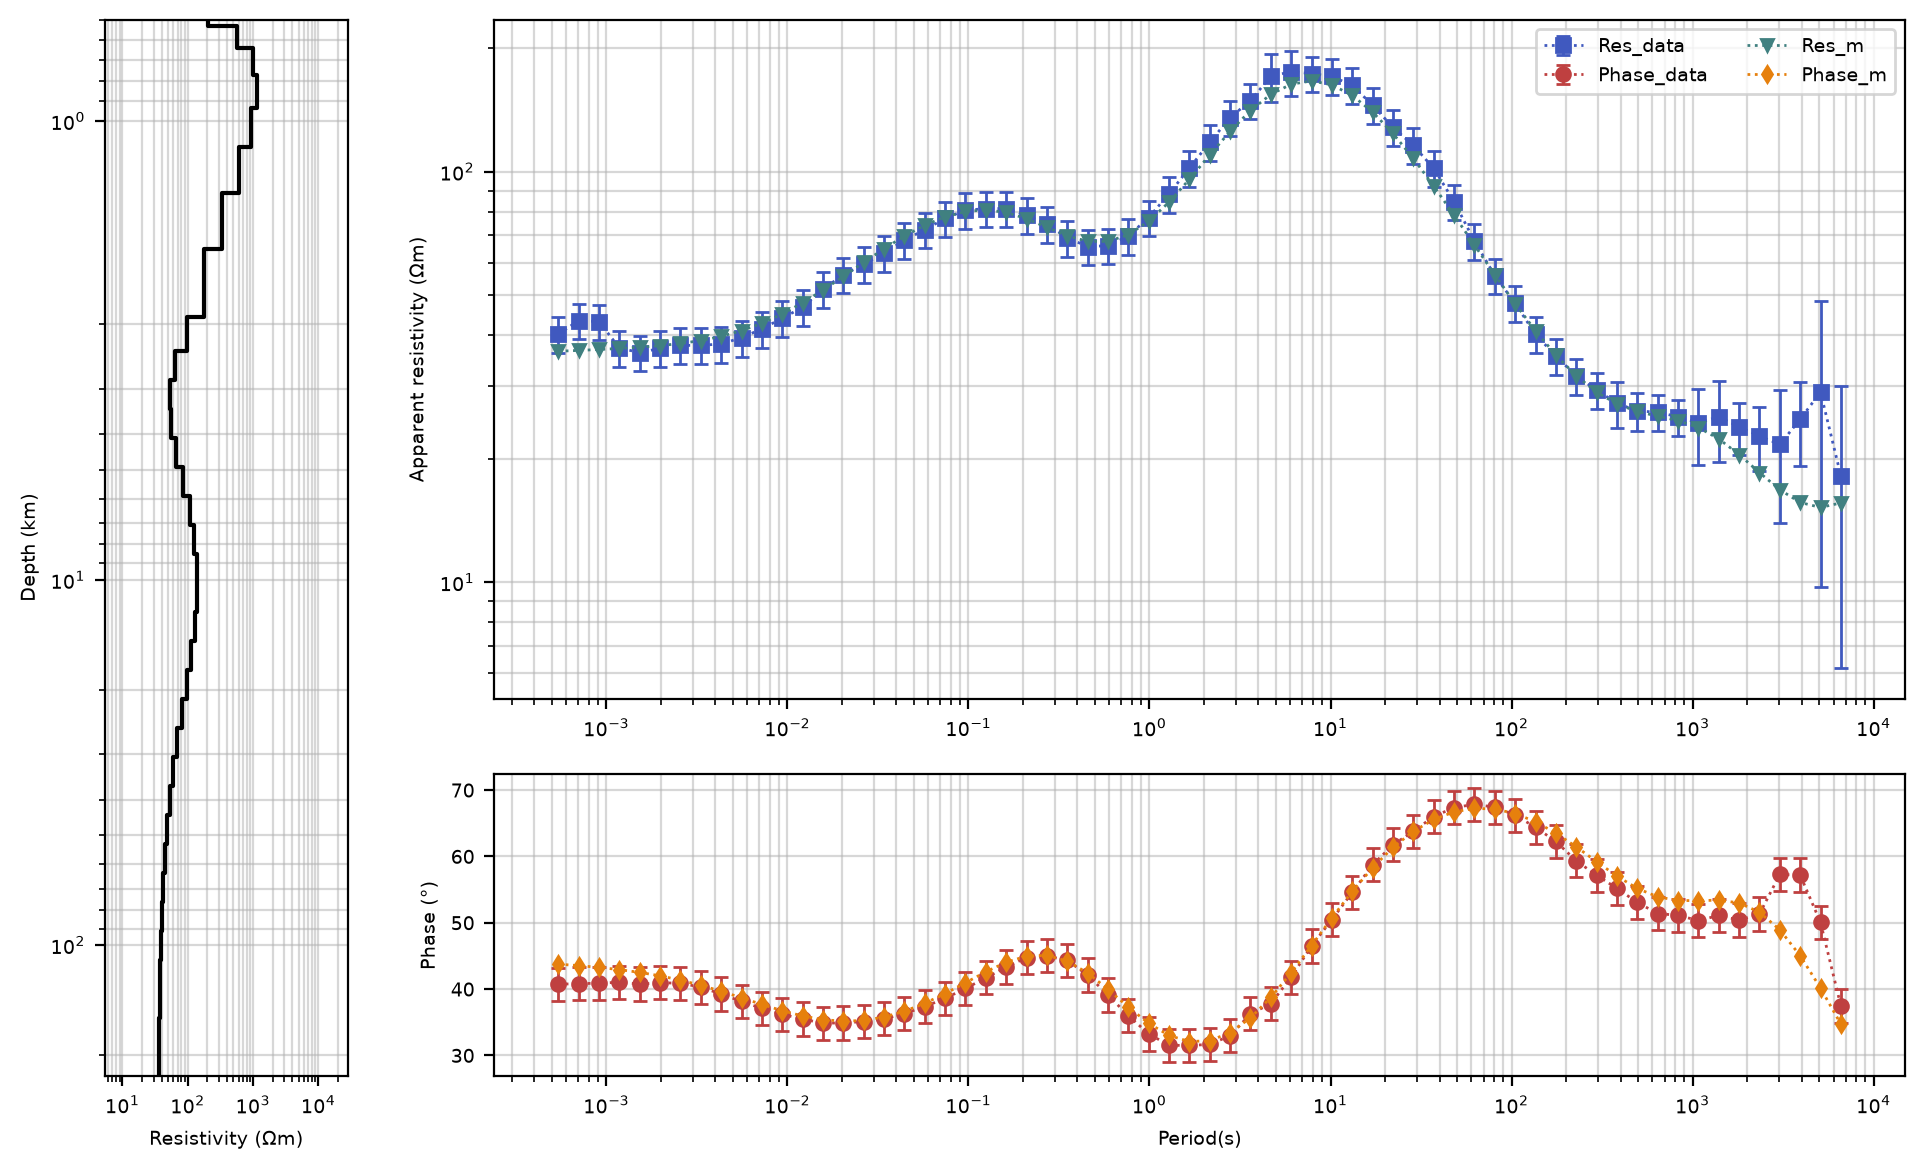

In [6]:
tf.compute_model_z_errors(error_value=3, error_type="data")
inv_obj = tf.to_simpeg_1d(mode="det", **{"p_s": 2, "p_z": 0, "use_irls": False})

INFO: 
simpeg.InvProblem is setting bfgsH0 to the inverse of the reg.deriv2.
using the default solver SolverLU with the 'is_symmetric=True` option set.




Running inversion with SimPEG v0.25.2
============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
   0  1.27e+03  1.08e+04  0.00e+00  1.08e+04                                 
   1  1.27e+03  1.05e+03  7.18e-04  1.05e+03    5.24e+03      0              
   2  6.37e+02  2.17e+02  5.52e-03  2.20e+02    6.95e+02      0   Skip BFGS  
   3  3.19e+02  8.63e+01  1.13e-02  8.99e+01    1.76e+02      0              
Reached starting chifact with l2-norm regularization: Start IRLS steps...
irls_threshold 5.342410083120039
   4  3.19e+02  4.60e+01  4.14e-04  4.61e+01    1.21e+02      1              
   5  7.62e+02  4.27e+01  5.64e-04  4.32e+01    5.97e+01      0              
   6  1.90e+03  3.07e+01  1.16e-03  3.29e+01    4.92e+01      0              
   7  5.87e+03  3.10e+01  9.86e-04  3.68e+01    1.69e+01      1   Skip BF

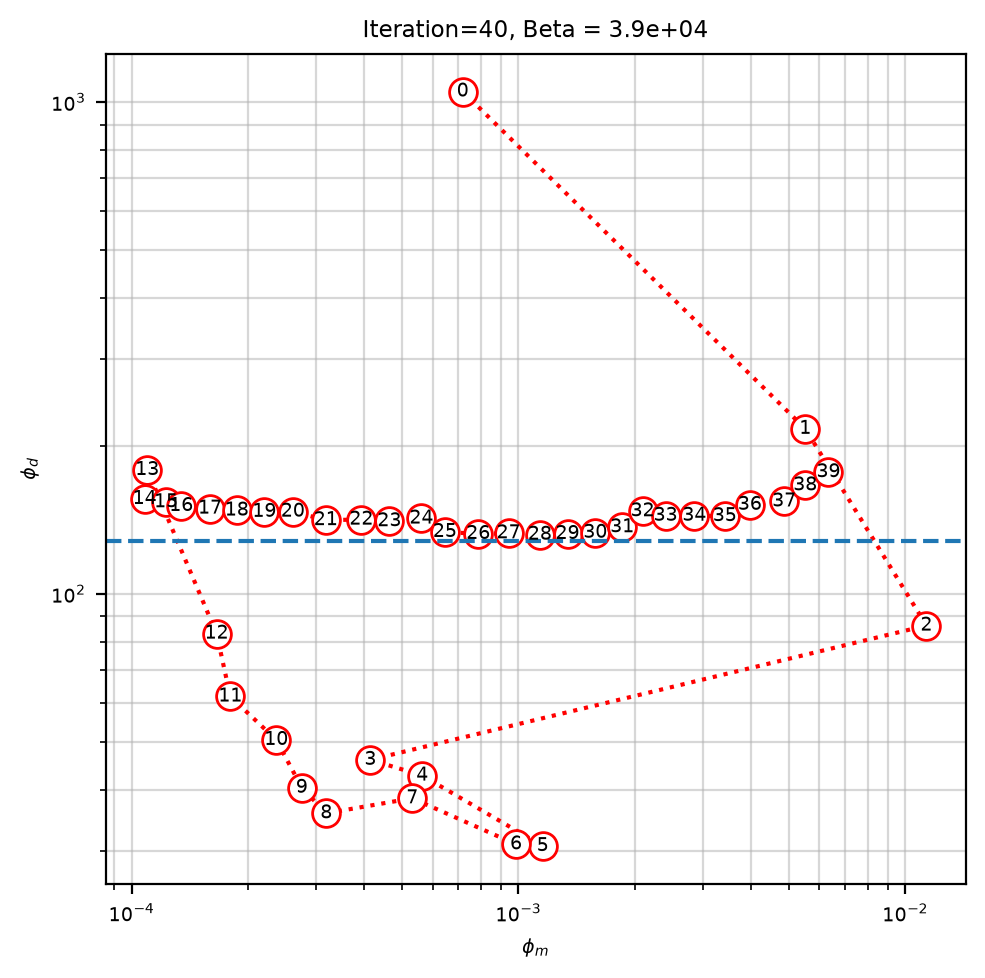

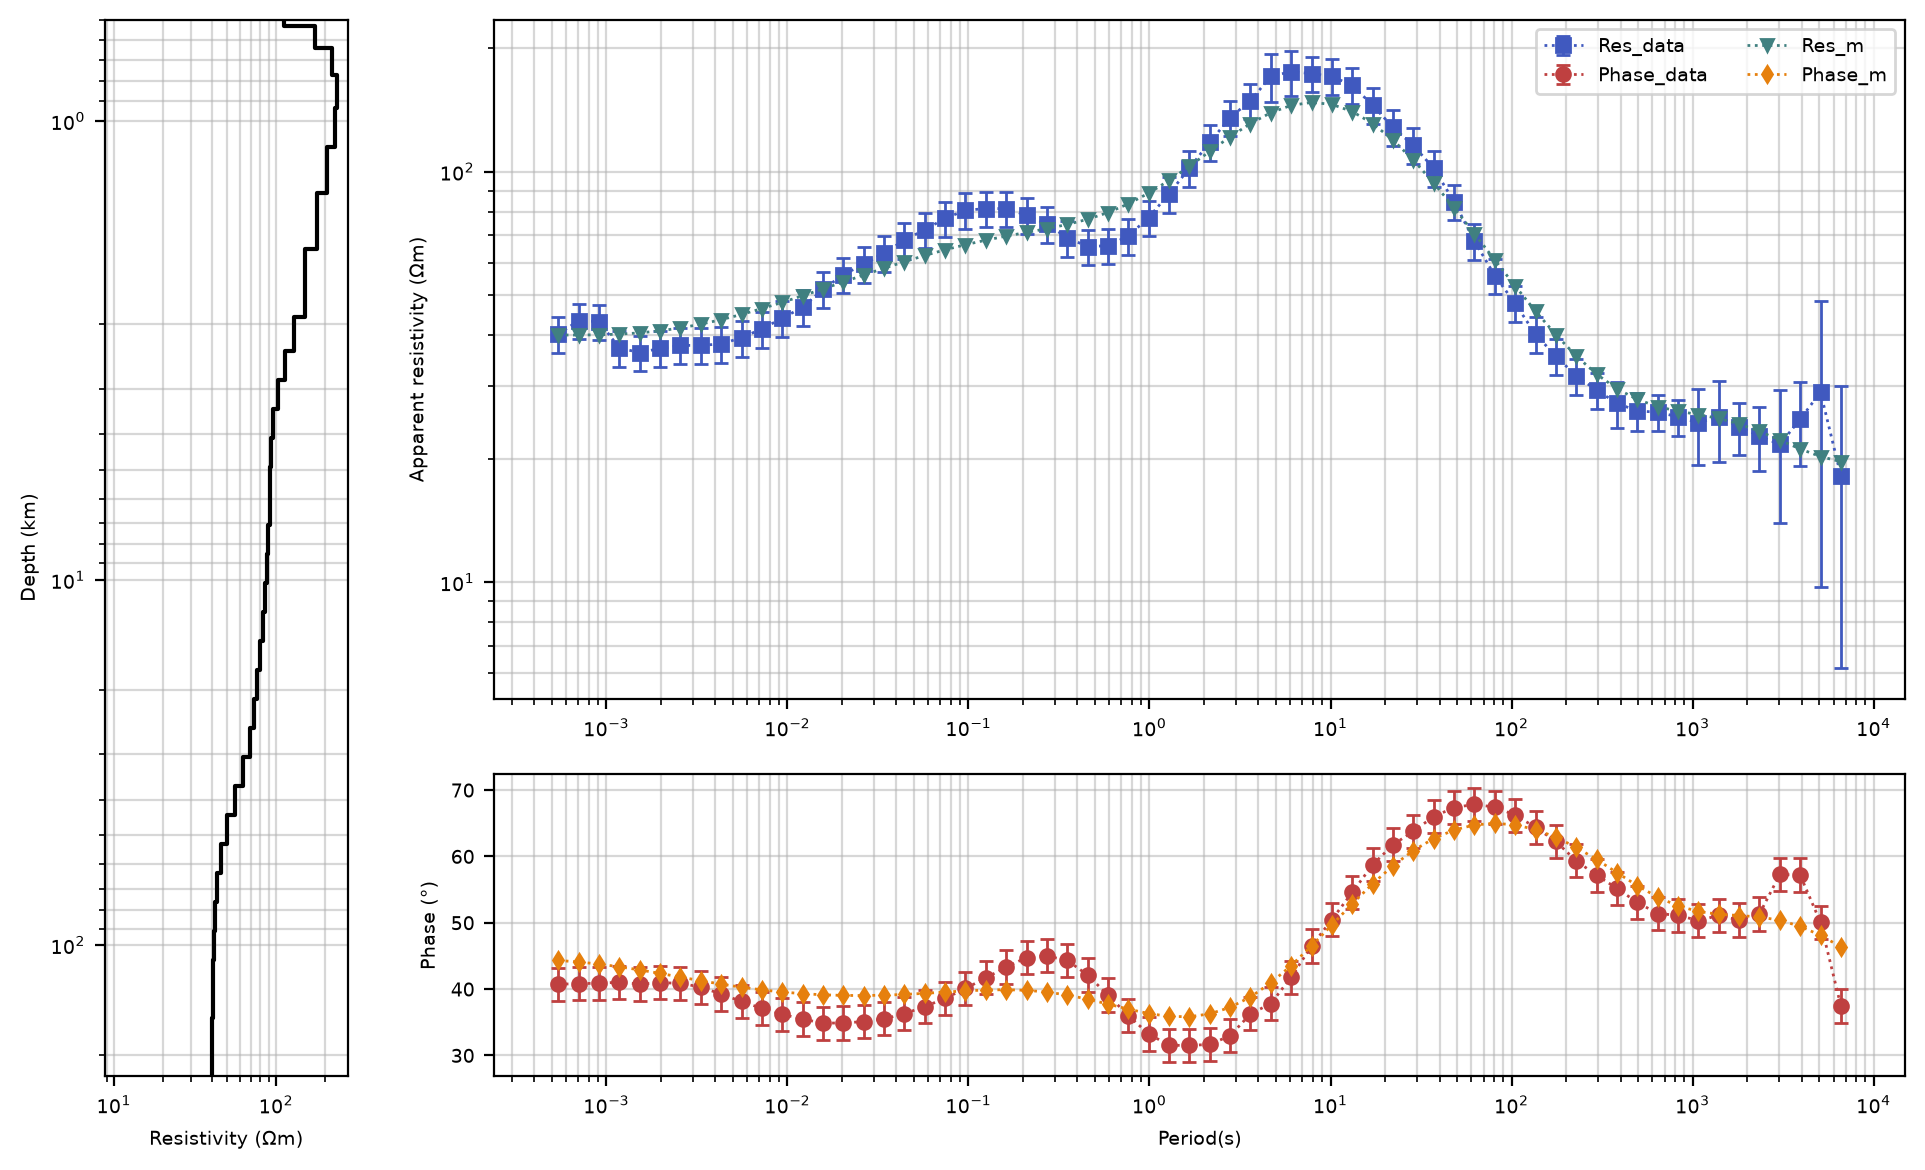

In [7]:
inv_obj = tf.to_simpeg_1d(mode="det", **{"p_s": 0, "p_z": 0, "use_irls": True})